## V2 - VAE

### Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
for item in os.listdir('/content/drive/MyDrive/24135120_Shiva Saitej Sharma T/HiRise'):
    print(item)

labels-map-proj_v3_2_train_val_test.txt
normal_30k_folder
dataset_split


In [3]:
!cp -r "/content/drive/MyDrive/24135120_Shiva Saitej Sharma T/HiRise/dataset_split" /content/dataset_split

In [7]:
import os
print(os.listdir('/content/dataset_split'))

['dataset_split']


In [8]:
import os
print(len(os.listdir('/content/dataset_split/dataset_split/train/normal')))
print(len(os.listdir('/content/dataset_split/dataset_split/test/normal')))
print(len(os.listdir('/content/dataset_split/dataset_split/test/anomaly_real')))

20049
2098
5125


In [9]:
DATASET_SPLIT_ROOT = '/content/dataset_split/dataset_split'

In [13]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_SPLIT_ROOT = '/content/dataset_split/dataset_split' # <-- EDIT IF NEEDED
SAVE_DIR = '/content/drive/MyDrive/hirise'                            # where model/results get saved

TRAIN_DIR = f'{DATASET_SPLIT_ROOT}/train/normal'
TEST_NORMAL_DIR = f'{DATASET_SPLIT_ROOT}/test/normal'
TEST_ANOMALY_DIR = f'{DATASET_SPLIT_ROOT}/test/anomaly_real'

IMG_SIZE = 128

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
print(os.path.exists('/content/dataset_split/dataset_split/train/normal'))

True


In [14]:
import os, glob, time, json
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from scipy import ndimage
from scipy.signal import convolve2d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
torch.manual_seed(0); np.random.seed(0)

class ImageFolderDataset(Dataset):
    def __init__(self, folder, img_size=IMG_SIZE):
        self.paths = sorted(glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png')))
        self.img_size = img_size
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        im = Image.open(self.paths[i]).convert('L').resize((self.img_size, self.img_size))
        arr = np.asarray(im, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)

print("Train:", len(glob.glob(TRAIN_DIR+'/*.jpg')), "images")
print("Test normal:", len(glob.glob(TEST_NORMAL_DIR+'/*.jpg')), "images")
print("Test anomaly:", len(glob.glob(TEST_ANOMALY_DIR+'/*.jpg')), "images")

device: cuda
Train: 20049 images
Test normal: 2098 images
Test anomaly: 5125 images


### Model

In [15]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64, base_ch=32, img_size=128):
        super().__init__()
        c = base_ch
        self.img_size = img_size
        self.enc = nn.Sequential(
            nn.Conv2d(1, c, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(c, c*2, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(c*2, c*4, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(c*4, c*8, 4, 2, 1), nn.ReLU(),
        )
        self.spatial = img_size // 16
        self.flat_dim = c*8*self.spatial*self.spatial
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(c*8, c*4, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(c*4, c*2, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(c*2, c, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(c, 1, 4, 2, 1), nn.Sigmoid(),
        )
        self.c = c
    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + torch.randn_like(std)*std
    def decode(self, z):
        h = self.fc_dec(z).view(-1, self.c*8, self.spatial, self.spatial)
        return self.dec(h)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon, x, mu, logvar, beta=0.5):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta*kld, recon_loss, kld


### Training

In [16]:
train_ds = ImageFolderDataset(TRAIN_DIR)
val_ds = ImageFolderDataset(TEST_NORMAL_DIR)   # held-out clean images, used to monitor + set threshold later
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

model = ConvVAE(latent_dim=64, base_ch=32, img_size=IMG_SIZE).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
history = []
t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    tot_loss=tot_recon=tot_kld=n=0
    for x in train_loader:
        x = x.to(device, non_blocking=True)
        recon, mu, logvar = model(x)
        loss, rl, kl = vae_loss(recon, x, mu, logvar, beta=0.5)
        opt.zero_grad(); loss.backward(); opt.step()
        bs = x.size(0)
        tot_loss += loss.item()*bs; tot_recon += rl.item()*bs; tot_kld += kl.item()*bs; n += bs
    model.eval()
    val_recon=vn=0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device, non_blocking=True)
            recon, mu, logvar = model(x)
            _, rl, _ = vae_loss(recon, x, mu, logvar)
            val_recon += rl.item()*x.size(0); vn += x.size(0)
    print(f"epoch {epoch+1}/{EPOCHS} train_recon={tot_recon/n:.4f} kld={tot_kld/n:.4f} val_recon={val_recon/vn:.4f}")
    history.append((epoch+1, tot_loss/n, tot_recon/n, tot_kld/n, val_recon/vn))
print('training time (s):', time.time()-t0)

torch.save(model.state_dict(), f'{SAVE_DIR}/vae_final.pt')
json.dump(history, open(f'{SAVE_DIR}/history_final.json','w'))
print("model saved")

epoch 1/30 train_recon=186.6005 kld=15.7972 val_recon=82.9358
epoch 2/30 train_recon=74.5720 kld=17.9489 val_recon=70.1559
epoch 3/30 train_recon=67.6637 kld=16.2957 val_recon=64.7310
epoch 4/30 train_recon=62.6449 kld=17.5150 val_recon=60.7700
epoch 5/30 train_recon=60.4286 kld=18.9347 val_recon=59.3561
epoch 6/30 train_recon=59.0781 kld=19.8492 val_recon=58.6441
epoch 7/30 train_recon=58.0274 kld=20.2136 val_recon=57.6370
epoch 8/30 train_recon=57.3235 kld=19.9856 val_recon=56.8429
epoch 9/30 train_recon=56.2180 kld=19.5976 val_recon=55.7661
epoch 10/30 train_recon=55.4945 kld=19.9458 val_recon=55.1127
epoch 11/30 train_recon=55.4672 kld=20.1849 val_recon=54.8863
epoch 12/30 train_recon=54.5693 kld=20.4182 val_recon=54.4337
epoch 13/30 train_recon=53.9387 kld=20.5618 val_recon=53.6841
epoch 14/30 train_recon=53.5215 kld=20.7196 val_recon=53.3346
epoch 15/30 train_recon=53.3026 kld=20.7623 val_recon=53.1384
epoch 16/30 train_recon=53.0042 kld=20.7996 val_recon=53.3974
epoch 17/30 trai

In [17]:
def patch_max_score(x, recon, patch=16):
    err = (recon - x)**2
    pooled = F.avg_pool2d(err, kernel_size=patch, stride=patch)
    return pooled.amax(dim=[1,2,3]).cpu().numpy()

def score_folder(folder):
    ds = ImageFolderDataset(folder)
    loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2)
    scores = []
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            scores.extend(patch_max_score(x, recon, patch=IMG_SIZE//8).tolist())
    return np.array(scores), ds.paths

model.eval()
normal_scores, normal_paths = score_folder(TEST_NORMAL_DIR)
anomaly_scores, anomaly_paths = score_folder(TEST_ANOMALY_DIR)

print(f"normal: n={len(normal_scores)}, mean={normal_scores.mean():.5f}")
print(f"anomaly: n={len(anomaly_scores)}, mean={anomaly_scores.mean():.5f}")

normal: n=2098, mean=0.01908
anomaly: n=5125, mean=0.04917


### ROC AUC Curve Result


>>> OVERALL AUC (real sensor-defect anomalies): 0.8599
>>> Threshold (95th pct of normal): 0.04929
>>> Flagged rate on normal test set: 0.050
>>> Flagged rate on anomaly test set: 0.407


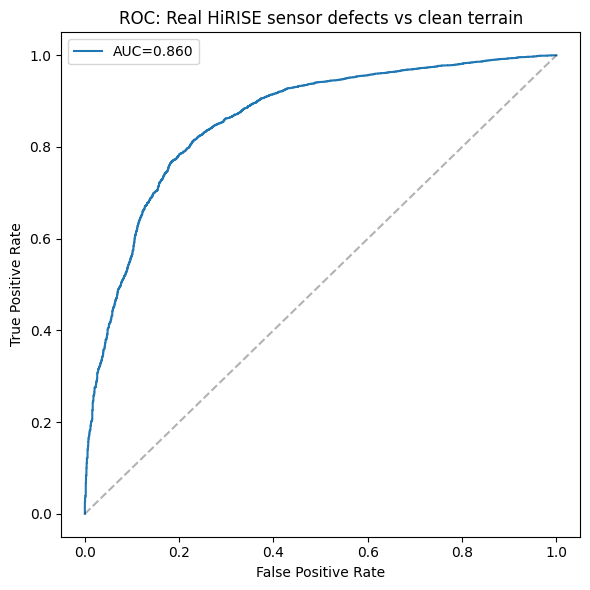

In [ ]:
y = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anomaly_scores))])
scores_all = np.concatenate([normal_scores, anomaly_scores])
overall_auc = roc_auc_score(y, scores_all)
threshold = np.percentile(normal_scores, 95)

print(f"\n>>> OVERALL AUC (real sensor-defect anomalies): {overall_auc:.4f}")
print(f">>> Threshold (95th pct of normal): {threshold:.5f}")
print(f">>> Flagged rate on normal test set: {(normal_scores > threshold).mean():.3f}")
print(f">>> Flagged rate on anomaly test set: {(anomaly_scores > threshold).mean():.3f}")

json.dump({'overall_auc': float(overall_auc), 'threshold': float(threshold)},
          open(f'{SAVE_DIR}/final_auc_results.json','w'), indent=2)

# ROC curve plot
fpr, tpr, _ = roc_curve(y, scores_all)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC={overall_auc:.3f}')
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC: Real HiRISE sensor defects vs clean terrain')
plt.legend(); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_final_roc.png', dpi=120)
plt.show()

In [19]:
def laplacian_variance(img):
    kernel = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
    lap = convolve2d(img, kernel, mode='valid')
    return lap.var()

def largest_blob_size(err_map, thresh_pct=90):
    thresh = np.percentile(err_map, thresh_pct)
    binary = err_map > thresh
    labeled, num = ndimage.label(binary)
    if num == 0: return 0
    sizes = ndimage.sum(binary, labeled, range(1, num+1))
    return sizes.max() if len(sizes) > 0 else 0

# recompute recon + error maps for the flagged anomaly images specifically
flagged_idx = np.where(anomaly_scores > threshold)[0]
flagged_paths = [anomaly_paths[i] for i in flagged_idx]
print(f"\n{len(flagged_paths)} anomaly images flagged above threshold (out of {len(anomaly_paths)})")

imgs_flagged = np.stack([np.asarray(Image.open(p).convert('L').resize((IMG_SIZE,IMG_SIZE)), dtype=np.float32)/255.0 for p in flagged_paths])
batch = torch.from_numpy(imgs_flagged).unsqueeze(1).to(device)
with torch.no_grad():
    recons_flagged = []
    for i in range(0, len(batch), 64):
        r, mu, logvar = model(batch[i:i+64])
        recons_flagged.append(r.cpu())
    recons_flagged = torch.cat(recons_flagged).numpy().squeeze(1)
error_maps_flagged = (recons_flagged - imgs_flagged) ** 2

features = []
for i in range(len(imgs_flagged)):
    f1 = largest_blob_size(error_maps_flagged[i])
    f2 = laplacian_variance(imgs_flagged[i])
    features.append([f1, f2])
features = np.array(features)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)  # 2 clusters: matches the 2 real defect types found
cluster_labels = kmeans.fit_predict(features_scaled)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster centers (blob_size, laplacian_var):")
for i,c in enumerate(centers): print(f"  cluster {i}: {c}")

# With only 2 clusters, rank by blob_size (bigger blob = Corrupted Crop)
# and assign the other cluster to Sensor Artifact -- guarantees no collision
crop_cluster = np.argmax(centers[:,0])
artifact_cluster = 1 - crop_cluster   # the other cluster, by construction
print("\nCluster centers (blob_size, laplacian_var):")
for i,c in enumerate(centers): print(f"  cluster {i}: {c}")
print(f"Corrupted Crop cluster: {crop_cluster}, Sensor Artifact cluster: {artifact_cluster}")
print(f"Counts: {np.bincount(cluster_labels)}")

results_df = pd.DataFrame({'filepath': flagged_paths,
                            'predicted_type': ['Corrupted Crop' if c==crop_cluster else 'Sensor Artifact' for c in cluster_labels]})
results_df.to_csv(f'{SAVE_DIR}/flagged_anomaly_categories.csv', index=False)
print(f"\nSaved categorized results to flagged_anomaly_categories.csv")
print(results_df['predicted_type'].value_counts())

print("""
NOTE: This screening method (line-dropout / edge-void detection) only
covers 'Sensor Artifact' and 'Corrupted Crop'. It CANNOT detect
'Non-Martian Content' since that requires content that looks
structurally different, not just black/void pixels. If your report
needs to address that 3rd category, either (a) note honestly that no
genuine non-Martian contamination was found via this method, or
(b) separately create a few synthetic non-Martian examples as a
proof-of-concept for that category only.
""")


2084 anomaly images flagged above threshold (out of 5125)

Cluster centers (blob_size, laplacian_var):
  cluster 0: [6.40219209e+02 8.50554061e-03]
  cluster 1: [1.23129525e+03 4.75576894e-03]

Cluster centers (blob_size, laplacian_var):
  cluster 0: [6.40219209e+02 8.50554061e-03]
  cluster 1: [1.23129525e+03 4.75576894e-03]
Corrupted Crop cluster: 1, Sensor Artifact cluster: 0
Counts: [ 885 1199]

Saved categorized results to flagged_anomaly_categories.csv
predicted_type
Corrupted Crop     1199
Sensor Artifact     885
Name: count, dtype: int64

NOTE: This screening method (line-dropout / edge-void detection) only
covers 'Sensor Artifact' and 'Corrupted Crop'. It CANNOT detect
'Non-Martian Content' since that requires content that looks
structurally different, not just black/void pixels. If your report
needs to address that 3rd category, either (a) note honestly that no
genuine non-Martian contamination was found via this method, or
(b) separately create a few synthetic non-Martian e

### Anomalies

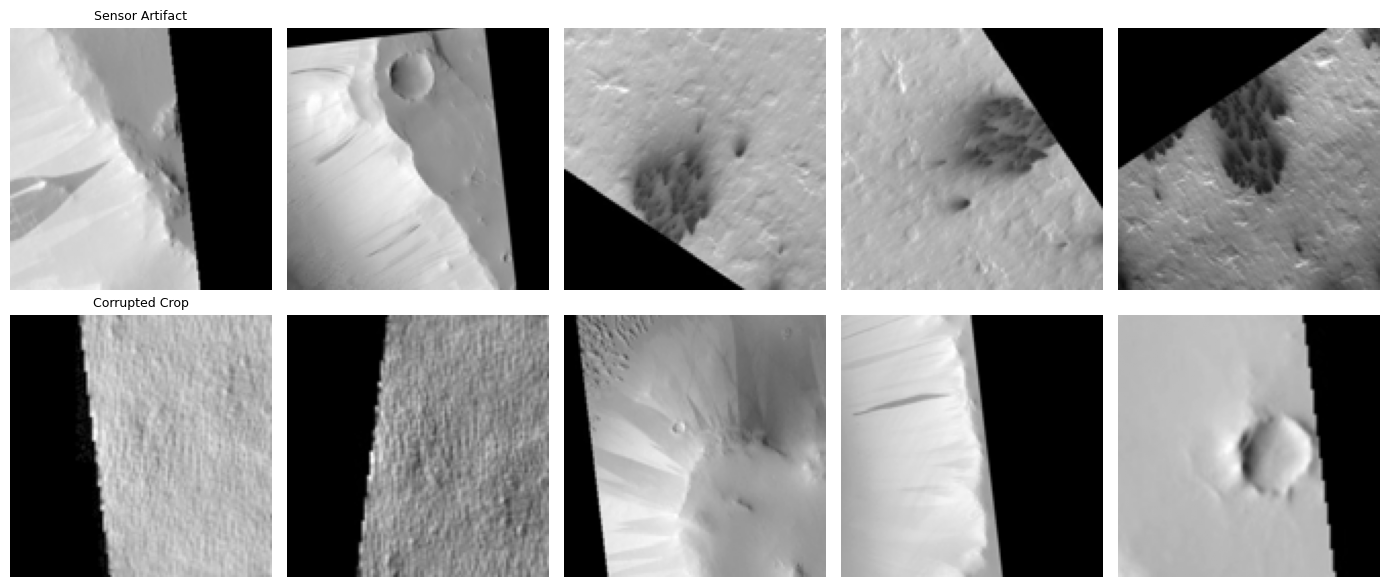

Saved fig_final_categories.png


In [20]:
fig, axes = plt.subplots(2, 5, figsize=(14,6))
for row, cluster_id in enumerate([artifact_cluster, crop_cluster]):
    idxs = np.where(cluster_labels == cluster_id)[0][:5]
    label = 'Sensor Artifact' if cluster_id==artifact_cluster else 'Corrupted Crop'
    for j, idx in enumerate(idxs):
        axes[row, j].imshow(imgs_flagged[idx], cmap='gray')
        axes[row, j].set_title(label if j==0 else '', fontsize=9)
        axes[row, j].axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_final_categories.png', dpi=120)
plt.show()
print("Saved fig_final_categories.png")

### Error Map

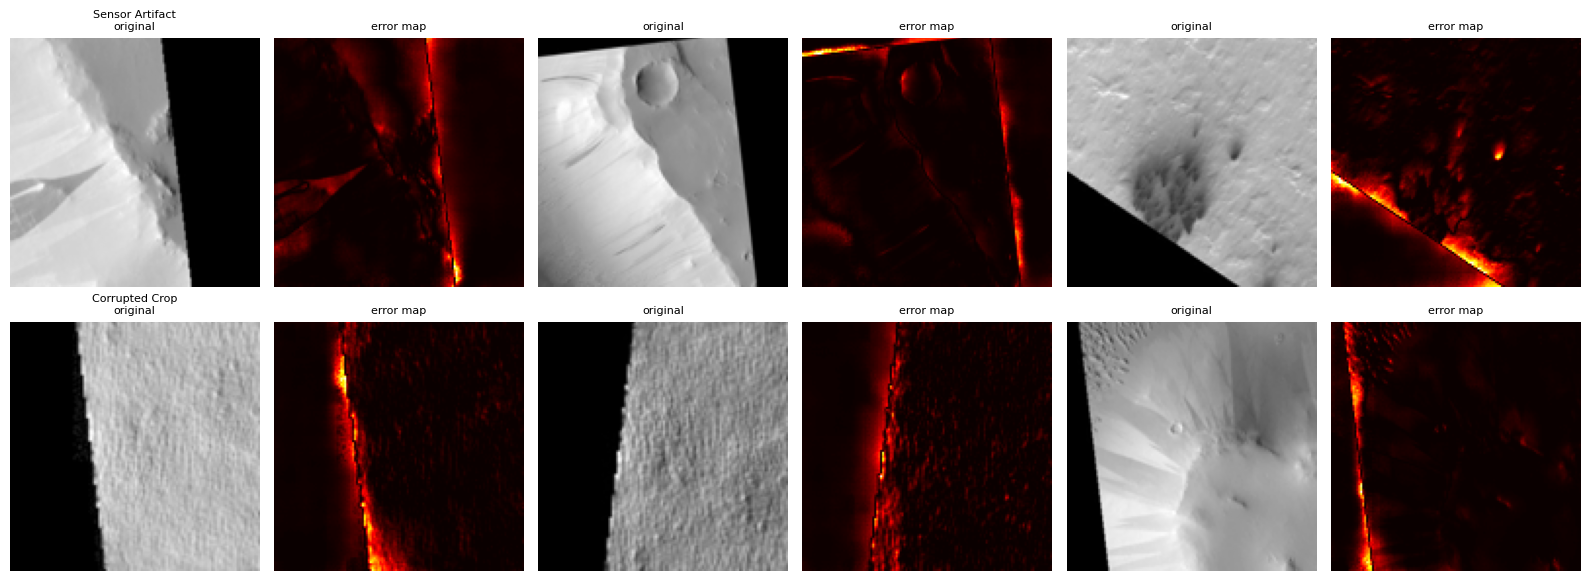

Saved fig_final_error_heatmaps.png -- this is your explanation-mechanism figure for the report


In [21]:
fig, axes = plt.subplots(2, 6, figsize=(16,6))
for row, cluster_id in enumerate([artifact_cluster, crop_cluster]):
    idxs = np.where(cluster_labels == cluster_id)[0][:3]
    label = 'Sensor Artifact' if cluster_id==artifact_cluster else 'Corrupted Crop'
    for j, idx in enumerate(idxs):
        axes[row, j*2].imshow(imgs_flagged[idx], cmap='gray')
        axes[row, j*2].set_title(f'{label}\noriginal' if j==0 else 'original', fontsize=8)
        axes[row, j*2].axis('off')
        axes[row, j*2+1].imshow(error_maps_flagged[idx], cmap='hot')
        axes[row, j*2+1].set_title('error map', fontsize=8)
        axes[row, j*2+1].axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_final_error_heatmaps.png', dpi=120)
plt.show()
print("Saved fig_final_error_heatmaps.png -- this is your explanation-mechanism figure for the report")

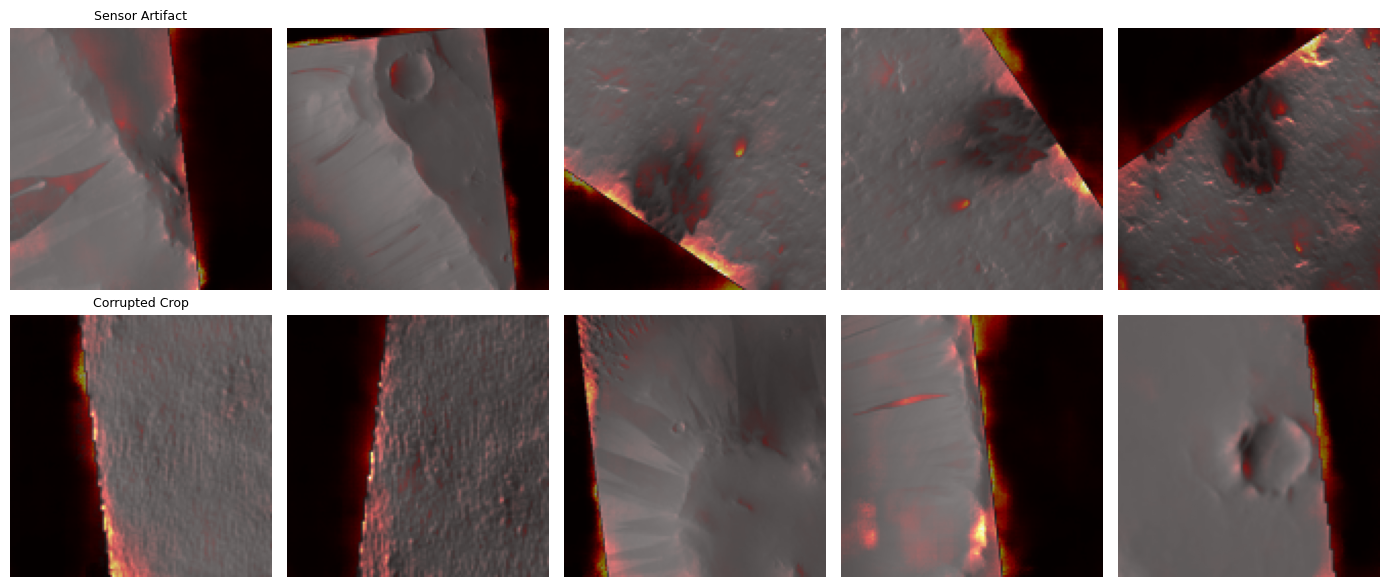

Saved fig_final_overlay.png


In [22]:
fig, axes = plt.subplots(2, 5, figsize=(14,6))
for row, cluster_id in enumerate([artifact_cluster, crop_cluster]):
    idxs = np.where(cluster_labels == cluster_id)[0][:5]
    label = 'Sensor Artifact' if cluster_id==artifact_cluster else 'Corrupted Crop'
    for j, idx in enumerate(idxs):
        axes[row, j].imshow(imgs_flagged[idx], cmap='gray')
        axes[row, j].imshow(error_maps_flagged[idx], cmap='hot', alpha=0.5)  # semi-transparent overlay
        axes[row, j].set_title(label if j==0 else '', fontsize=9)
        axes[row, j].axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_final_overlay.png', dpi=120)
plt.show()
print("Saved fig_final_overlay.png")

In [23]:
RUN_NAME = 'v2_full_anomaly_set'   # change this each time you do a new run

In [24]:
sd = torch.load(f'{SAVE_DIR}/vae_final.pt', map_location='cpu')
print(len(sd), "tensors")
print(list(sd.keys())[:3])

22 tensors
['enc.0.weight', 'enc.0.bias', 'enc.2.weight']
